<a href="https://colab.research.google.com/github/NikhilaVecham/FoodHub-FoodDelivery-DataAnalysis/blob/main/PYF_Project_Learner_Notebook_Full_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 -q --user

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# to restrict the float value to 3 decimal places
pd.set_option('display.float_format', lambda x: '%.3f' % x)

### Understanding the structure of the data

In [ ]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Write your code here to read the data
data = pd.read_csv("/content/drive/My Drive/Colab Notebooks/foodhub_order.csv")

In [ ]:
# Write your code here to view the first 5 rows
data.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.750,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.080,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.230,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.200,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.590,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
# checking shape of the data
data.shape
#print("There are", data.shape[0], "rows and", data.shape[1], "columns.")

(1898, 9)

#### Observations:
- There are 1898 rows and 9 columns present in the dataset


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
# Write your code here
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
-   The dataset contains 1898 rows and 9 columns.
-   There are 4 integer columns:
      - order_id
      - customer_id
      - food_preparation_time
      - delivery_time
-   The column cost_of_the_order is of float type.
-   There are 4 object columns:
      - restaurant_name
      - cuisine_type
      - day_of_the_week
      - rating.
-   All columns have non-null values.








### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
# Write your code here
data.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations:
- There are no missing values in the data


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
# Write your code here
data.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.000,1477495.500,548.050,1476547.000,1477021.250,1477495.500,1477969.750,1478444.000
customer_id,1898.000,171168.478,113698.140,1311.000,77787.750,128600.000,270525.000,405334.000
cost_of_the_order,1898.000,16.499,7.484,4.470,12.080,14.140,22.297,35.410
food_preparation_time,1898.000,27.372,4.632,20.000,23.000,27.000,31.000,35.000
delivery_time,1898.000,24.162,4.973,15.000,20.000,25.000,28.000,33.000


#### Observations:
- The above table displays the descriptive analysis for Numerical columns
- The minimum food preparation time is 20 minutes.
- The average food preparation time is 27.4 minutes.
- The maximum food preparation time is 35 minutes.

### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
# Write the code here
import pandas as pd

data = pd.read_csv("/content/drive/My Drive/Colab Notebooks/foodhub_order.csv")

not_rated_orders = data[data['rating'] == 'Not given'].shape[0]
total_orders = data.shape[0]

print("Number of orders not rated:", not_rated_orders)
print("Total orders:", total_orders)


Number of orders not rated: 736
Total orders: 1898


#### Observations:
- There are 736 orders that are not rated.


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

### **Cleaning up 'rating' column before analysis**



In [ ]:
# Make a full copy
#copy data into df to clean up rating column in df
df = data.copy()

# Replacing Not given with Nan and converting it to numeric type
df["rating"] = df["rating"].replace("Not given", pd.NA)
df["rating"] = pd.to_numeric(df["rating"], errors='coerce')

# Verify types
print(df["rating"].dtype)


float64


### **Distribution on numerical columns**

### **observation on Order ID**

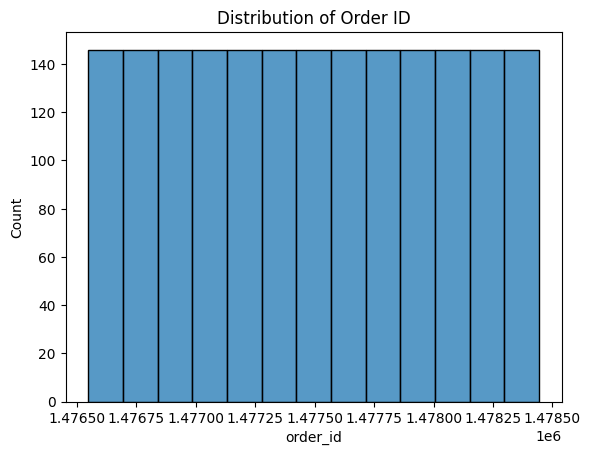

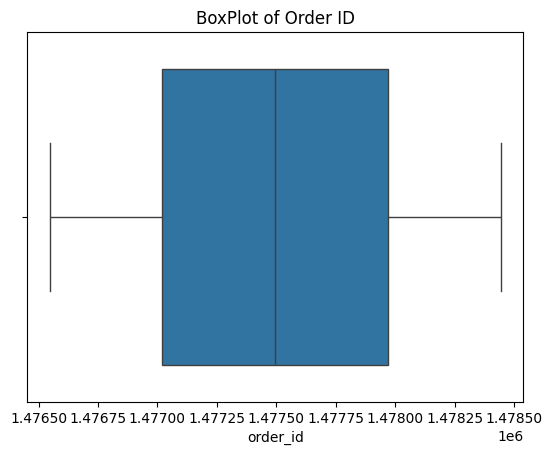

In [ ]:
sns.histplot(data=df,x='order_id')
plt.title("Distribution of Order ID")
plt.show()

sns.boxplot(data=df,x='order_id')
plt.title("BoxPlot of Order ID")
plt.show()

* symmetrically distributed
* unique reference. Cannot be used for any insights.

### **observation on customer_id**

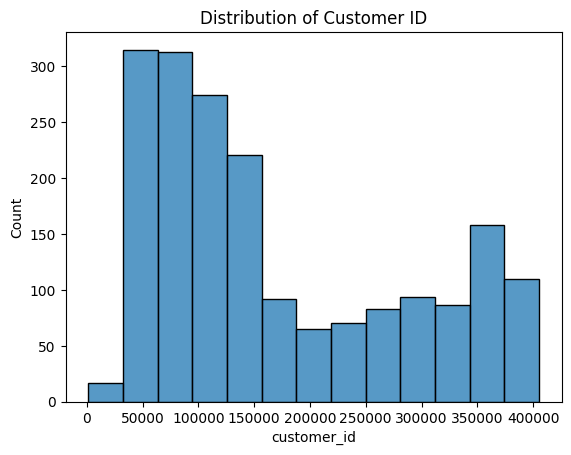

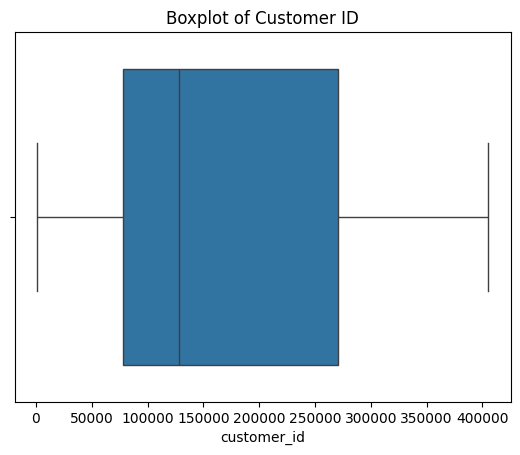

In [ ]:
sns.histplot(data=df,x='customer_id')
plt.title("Distribution of Customer ID")
plt.show()

sns.boxplot(data=df,x='customer_id')
plt.title("Boxplot of Customer ID")
plt.show()

* Many unique customers

### **observation on cost_of_the_order**

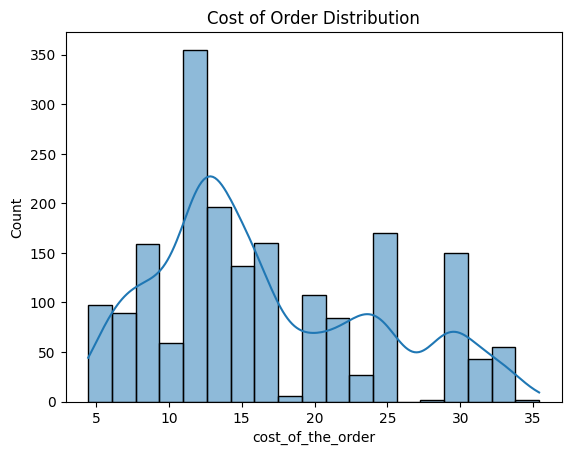

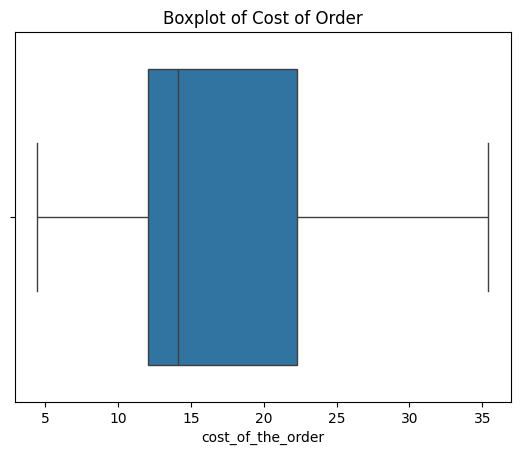

In [ ]:
# Write the code here
sns.histplot(data=df,x='cost_of_the_order',kde=True)
plt.title("Cost of Order Distribution")
plt.show()

sns.boxplot(data=df,x='cost_of_the_order')
plt.title("Boxplot of Cost of Order")
plt.show()


* The distribution is right skewed
* There are no outliers
* Most orders are between \$10 and $15

### **observation on food_preparation_time**

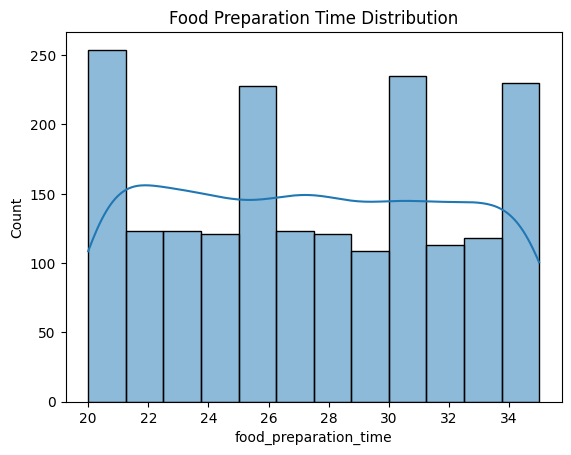

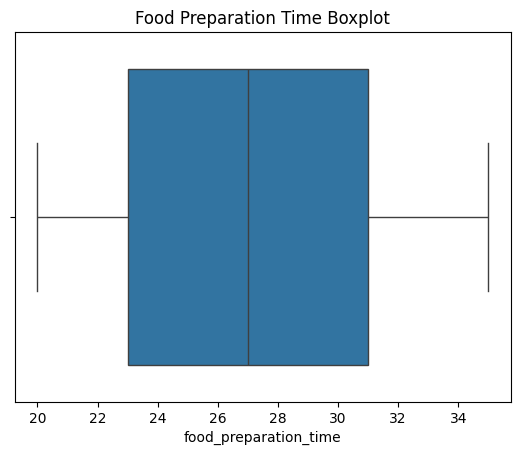

In [ ]:
sns.histplot(data=df,x='food_preparation_time',kde=True)
plt.title("Food Preparation Time Distribution")
plt.show()

sns.boxplot(data=df,x='food_preparation_time')
plt.title("Food Preparation Time Boxplot")
plt.show()

* symmetrically distributed
* Average food preparation time is between 26min and 28min

### **observation on delivery_time**



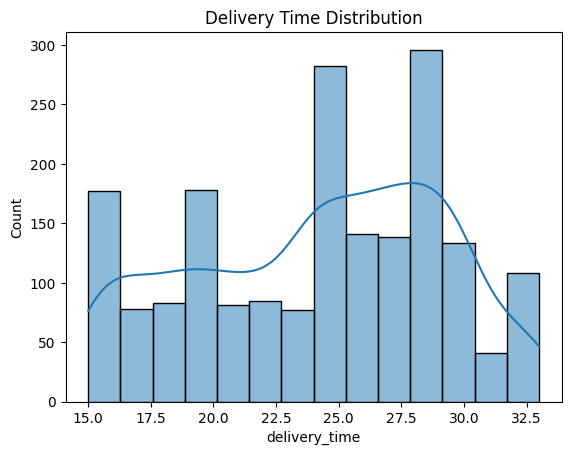

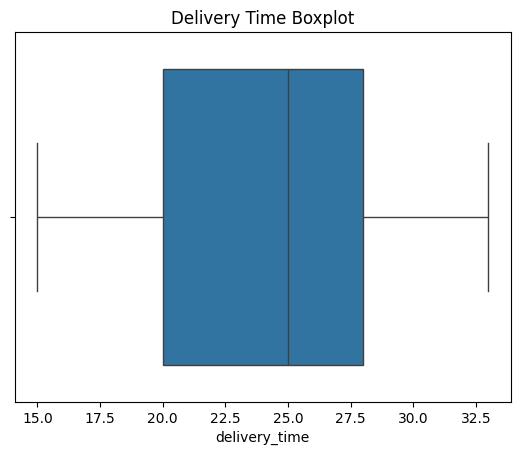

In [ ]:
#histplot
sns.histplot(data=df,x='delivery_time',kde=True)
plt.title("Delivery Time Distribution")
plt.show()

#Boxplot
sns.boxplot(data=df,x='delivery_time')
plt.title("Delivery Time Boxplot")
plt.show()

* Delivery time is mostly between 20 min and 28 min

### **observation on rating**

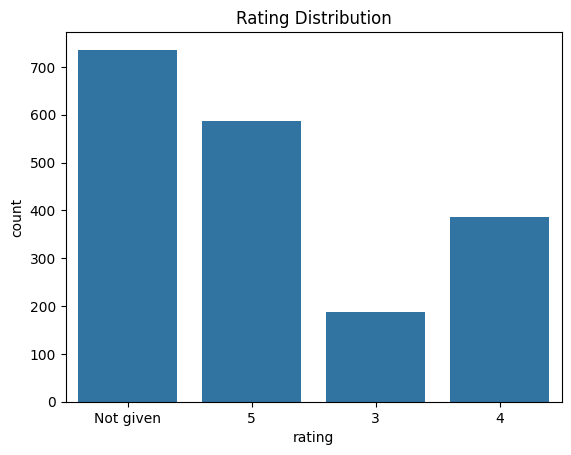

In [ ]:
#rating from 'data' ddatset before clean up.
sns.countplot(data=data, x='rating')
plt.title("Rating Distribution")
plt.show()

* Most of the ratings were 'Not given' rating before we clean up the rating data.

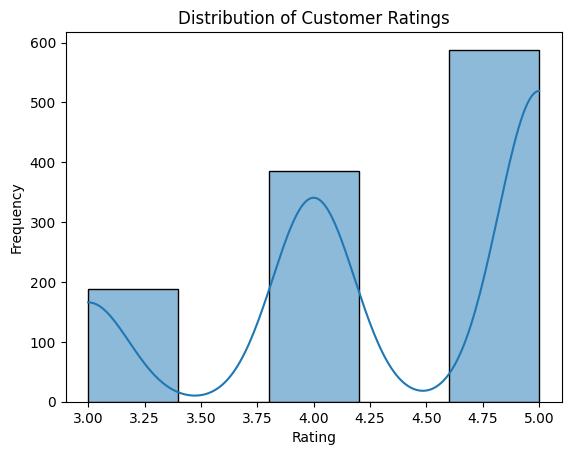

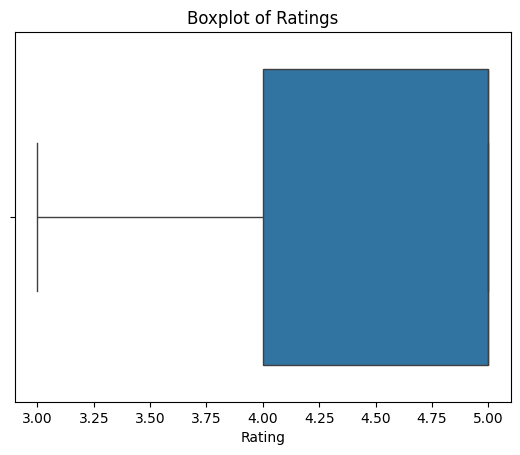

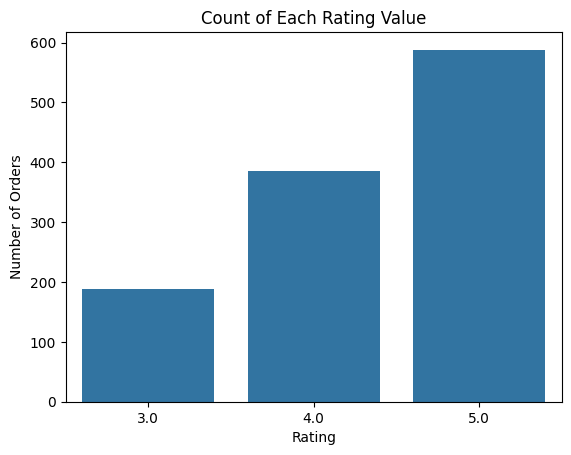

In [ ]:
#After cleaning up the rating data and using 'df' dataset
sns.histplot(df["rating"].dropna(), bins=5, kde=True)
plt.title("Distribution of Customer Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

#Boxplot
sns.boxplot(x=df["rating"])
plt.title("Boxplot of Ratings")
plt.xlabel("Rating")
plt.show()

#countplot
sns.countplot(x="rating", data=df, legend=False)
plt.title("Count of Each Rating Value")
plt.xlabel("Rating")
plt.ylabel("Number of Orders")
plt.show()


* Most frequent rating is 5
* Majority of the customers are happy with the service.

### **Distribution of categorical values**

### **observation on restaurant_name**

### cleaning up restaurant names
* Restaurant names have some special characters which are throwing some warnings. We are cleaning up the names to remove these warnings.

In [ ]:
df['restaurant_name'] = df['restaurant_name'].str.encode('ascii', 'ignore').str.decode('ascii')

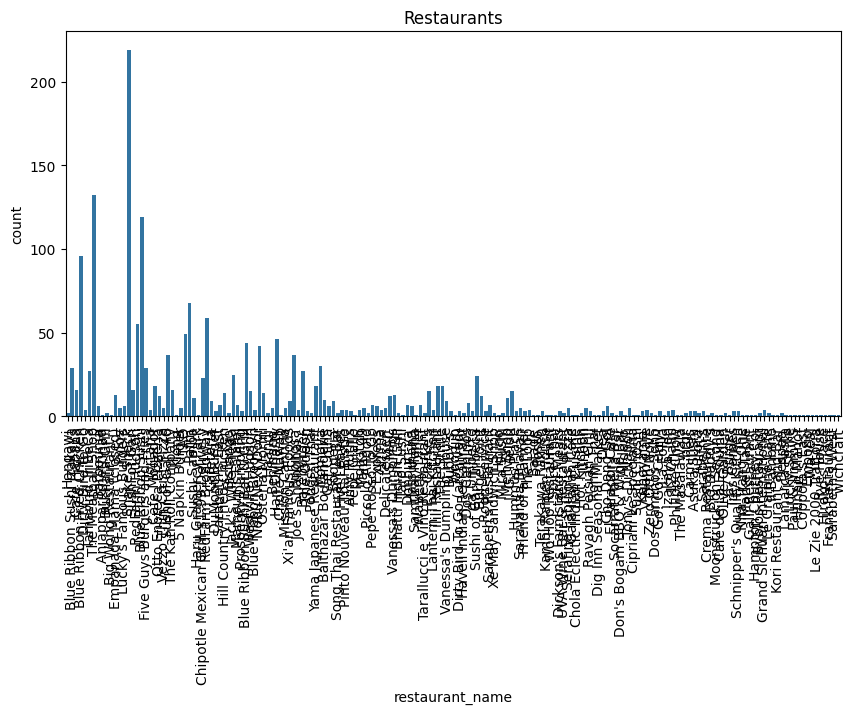

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x='restaurant_name')
plt.title("Restaurants")
plt.xticks(rotation=90)
plt.show()

* Very high number of restaurants

* A few restaurants have many orders, most have very few

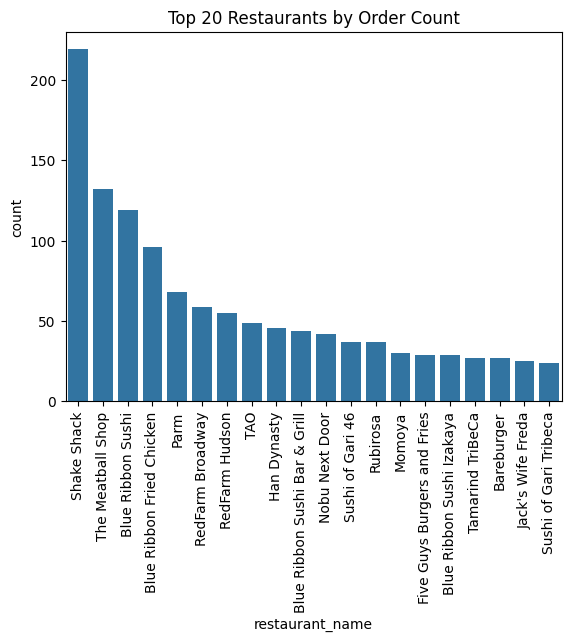

In [ ]:
#As there are so many restaurant names, the plot appears clumsy. So, lets plot for top 20.
top20 = df['restaurant_name'].value_counts().head(20).index
sns.countplot(data=df, order=top20, x='restaurant_name')
plt.title("Top 20 Restaurants by Order Count")
plt.xticks(rotation=90)
plt.show()

### **observation on cuisine_type**

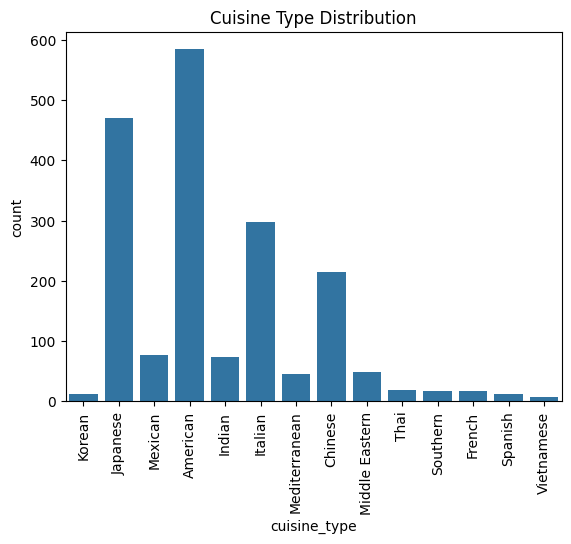

In [ ]:
sns.countplot(data=df,x='cuisine_type')
plt.title("Cuisine Type Distribution")
plt.xticks(rotation=90)
plt.show()

* Top 5 cuisines customers prefer are
1.   American
2.   Japanese
3.   Italian
4.   Chinese
5.   Mexican
* Most of the customers prefer American and Japanese


### **observation on day_of_the_week**

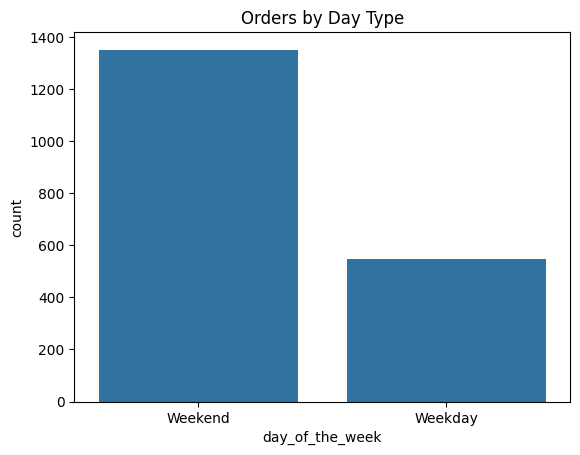

In [ ]:
sns.countplot(data=df, x='day_of_the_week')
plt.title("Orders by Day Type")
plt.show()

* Orders during the weekends are more than weekdays

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
top5 = (df['restaurant_name'].value_counts().head(5).reset_index())
top5.columns = ['restaurant_name', 'number_of_orders']
print(top5)


             restaurant_name  number_of_orders
0                Shake Shack               219
1          The Meatball Shop               132
2          Blue Ribbon Sushi               119
3  Blue Ribbon Fried Chicken                96
4                       Parm                68


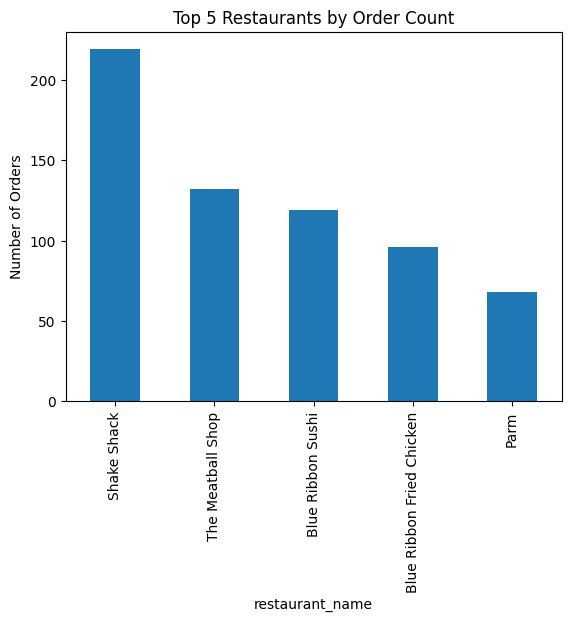

In [ ]:
# Write the code here
df['restaurant_name'].value_counts().head(5).plot(kind='bar')
plt.title("Top 5 Restaurants by Order Count")
plt.ylabel("Number of Orders")
plt.xticks(rotation=90)
plt.show()

#### Observations:
* The top 5 restaurants in terms of the number of orders received are
1.   Shake Shack
2.   The Meatball Shop
3.   Blue Ribbon Sushi
4.   Blue Ribbon Fried Chicken
5.   Parm





### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
# Write the code here
# Filter weekend orders
weekend_data = df[df['day_of_the_week'] == 'Weekend']

# Find most popular cuisine
most_popular_weekend_cuisine = weekend_data['cuisine_type'].value_counts().idxmax()

print("Most popular cuisine on weekends:", most_popular_weekend_cuisine)

Most popular cuisine on weekends: American


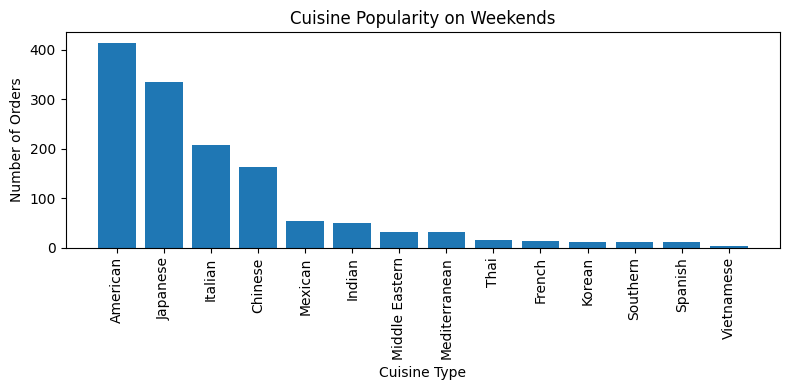

In [ ]:
# Filter weekend orders
weekend_data = df[df['day_of_the_week'] == 'Weekend']

# Count cuisines
cuisine_counts = weekend_data['cuisine_type'].value_counts()

plt.figure(figsize=(8,4))
plt.bar(cuisine_counts.index, cuisine_counts.values)
plt.xticks(rotation=90)
plt.xlabel("Cuisine Type")
plt.ylabel("Number of Orders")
plt.title("Cuisine Popularity on Weekends")
plt.tight_layout()
plt.show()


#### Observations:
* American cuisine receives the highest number of orders on weekends, making it the most popular cuisine.


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
# Write the code here
total_orders = df.shape[0]
orders_more_than_20 = df[df['cost_of_the_order']>20].shape[0]
orders_more_than_20_percentage = (orders_more_than_20/total_orders)*100
print(round(orders_more_than_20_percentage, 2), "%")


29.24 %


#### Observations:
* percentage of the orders cost more than 20 dollars is 29.24 %

### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
# Write the code here
# Calculate mean delivery time
mean_delivery_time = df['delivery_time'].mean()

print("Mean Order Delivery Time:", round(mean_delivery_time, 2), "minutes")

Mean Order Delivery Time: 24.16 minutes


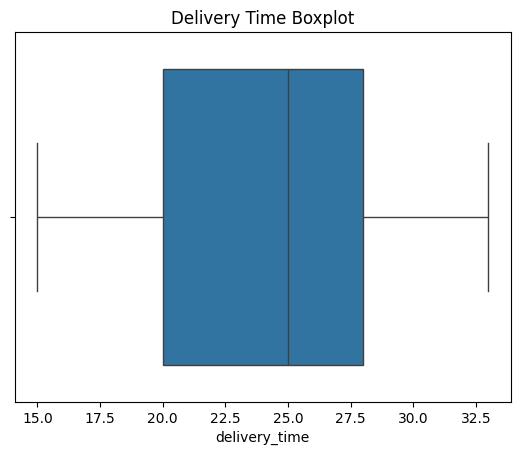

In [ ]:
#Boxplot
sns.boxplot(data=df,x='delivery_time')
plt.title("Delivery Time Boxplot")
plt.show()

#### Observations:
* The mean delivery time is about 24–25 minutes, indicating that most orders are delivered within half an hour.


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
# Write the code here
top_frequent_customers = df['customer_id'].value_counts().head(3).reset_index()
print("Top 3 most frequent customers: ")
top_frequent_customers.columns = ['Customer ID', 'Order Count']
top_frequent_customers

Top 3 most frequent customers: 


,Customer ID,Order Count
0,52832,13
1,47440,10
2,83287,9


#### **Observations:**
* customer 52832 placed 13 orders, who is the most frequent customer.
* customer 47440 is the second most frequent customer with 10 orders.
* customer 83287 is the third most frequent customer with 9 orders.


### **Multivariate Analysis**

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


### **Correlation between Numerical Values**

* For Multivariate analysis, I am Using 'df' dataset where we cleaned the 'rating column'
* As order_id and customer_id are unique identifiers, they will not add any value to our analysis.

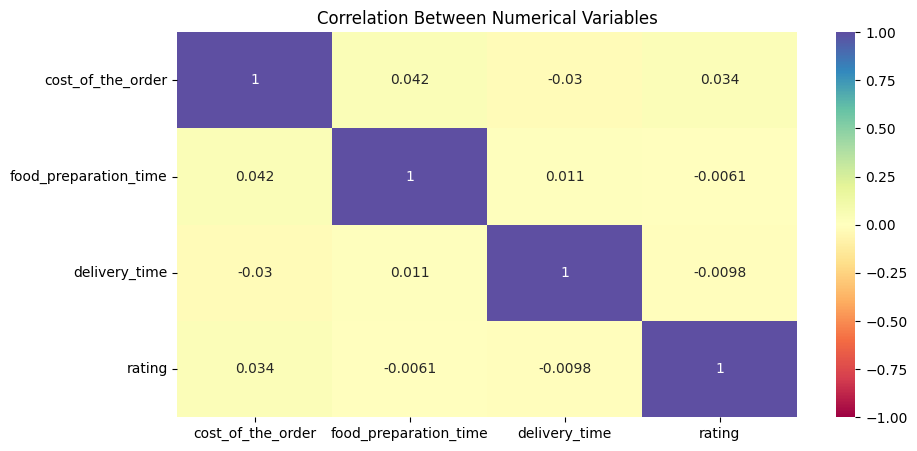

In [ ]:
plt.figure(figsize=(10,5))
num_cols = ['cost_of_the_order', 'food_preparation_time', 'delivery_time','rating']
sns.heatmap(df[num_cols].corr(),annot=True,cmap='Spectral',vmin=-1,vmax=1)
plt.title("Correlation Between Numerical Variables")
plt.show()

* The correlation among cost of the order, food preparation time, delivery time, and rating is weak, indicating minimal linear relationships between these variables.

### **Pairwise relationships between numerical variables**

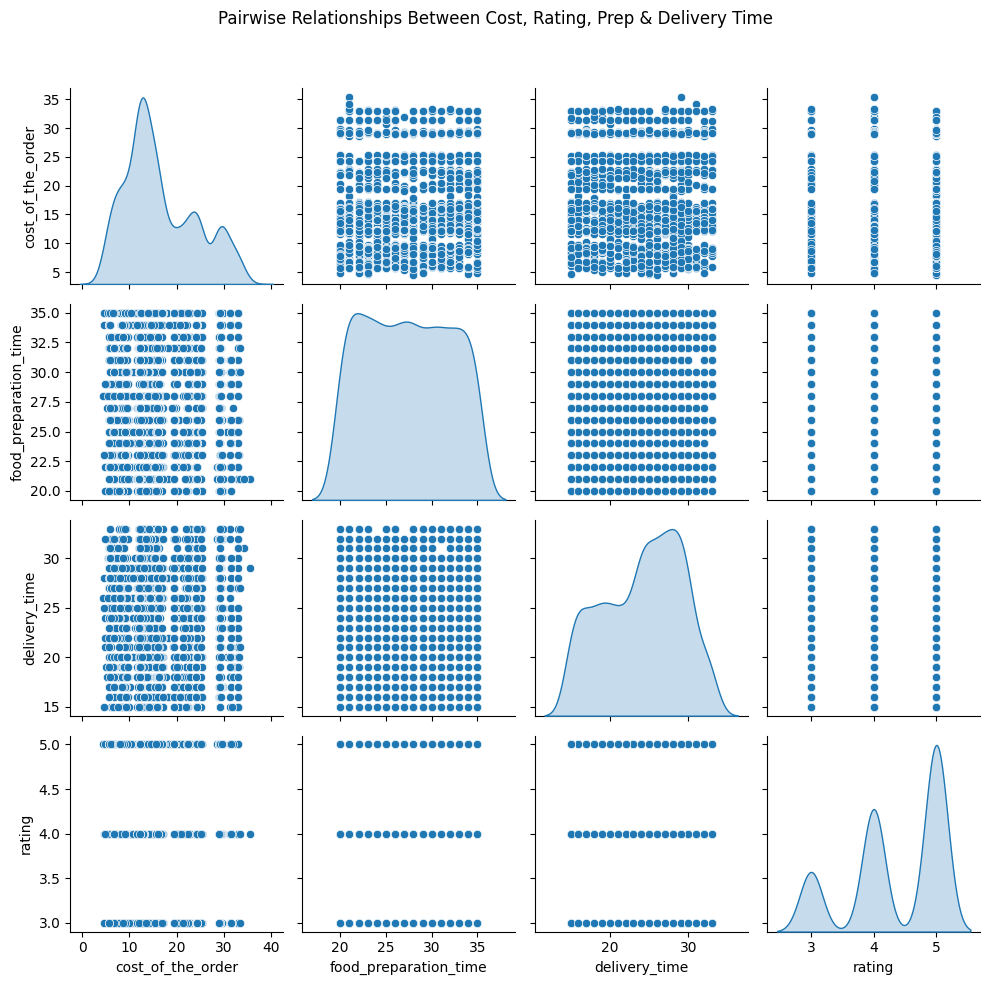

In [ ]:
numeric = ["cost_of_the_order", "food_preparation_time", "delivery_time","rating"]
sns.pairplot(df[numeric],diag_kind="kde")
plt.suptitle("Pairwise Relationships Between Cost, Rating, Prep & Delivery Time")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

* Scatterplots show no strong linear trends between the numerical variables, confirming low correlation across cost, preparation time, delivery time, and ratings.

### **Cost of order vs Delivery time**

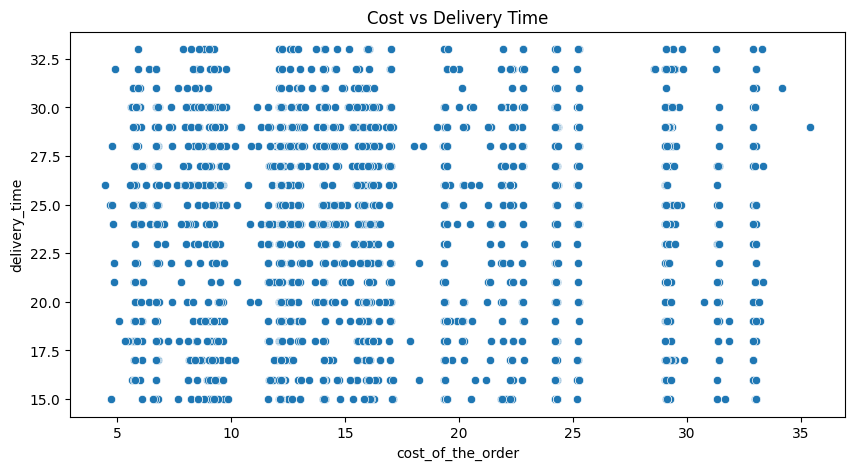

In [ ]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df,x='cost_of_the_order',y='delivery_time')
plt.title("Cost vs Delivery Time")
plt.show()

* Delivery time remains relatively constant across different order cost levels with no noticeable trend.

### **Food preparation time vs Delivery time**

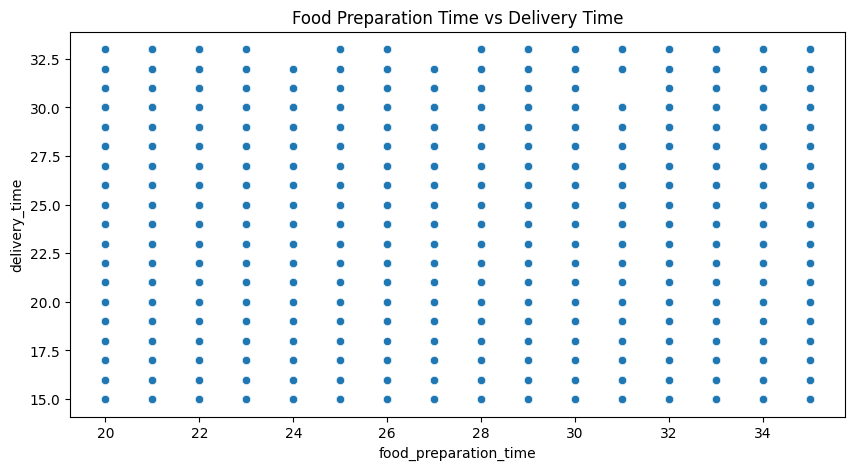

In [ ]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df,x='food_preparation_time',y='delivery_time')
plt.title("Food Preparation Time vs Delivery Time")
plt.show()


* There is no strong relationship between food_preparation time and delivery time.

### **Delivery time by Weekday vs Weekend**

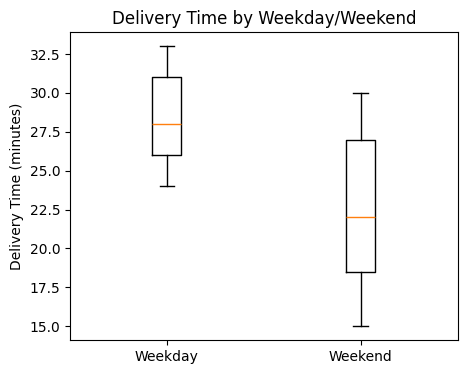

In [ ]:
weekday = df[df['day_of_the_week'] == 'Weekday']['delivery_time']
weekend = df[df['day_of_the_week'] == 'Weekend']['delivery_time']

plt.figure(figsize=(5,4))
plt.boxplot([weekday, weekend], tick_labels=['Weekday', 'Weekend'])
plt.ylabel("Delivery Time (minutes)")
plt.title("Delivery Time by Weekday/Weekend")
plt.show()

* Delivery times are higher on weekdays and lower on weekends.

### **Day of week vs Cost**

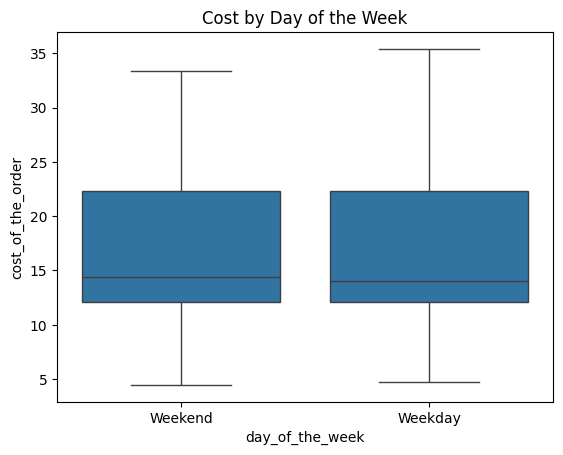

In [ ]:
sns.boxplot(data=df, x="day_of_the_week", y="cost_of_the_order")
plt.title("Cost by Day of the Week")
plt.show()


* Order costs show similar distributions for weekdays and weekends, with slightly more high-value orders occurring during weekends.

### **Restaurant name vs Delivery time**

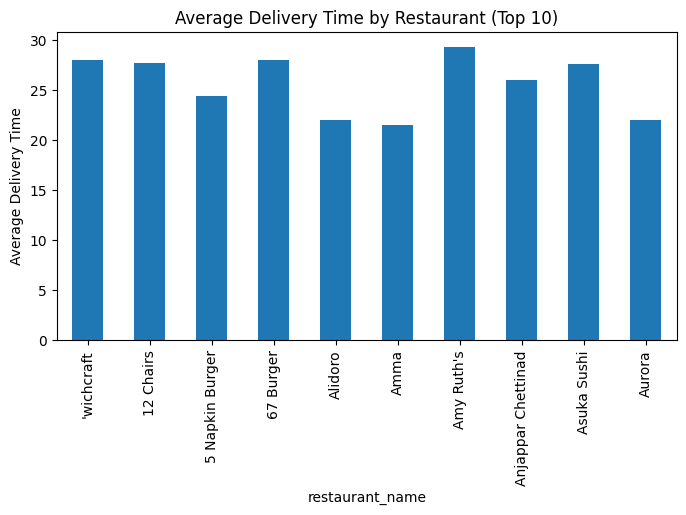

In [ ]:
avg_delivery = df.groupby('restaurant_name')['delivery_time'].mean().head(10)

avg_delivery.plot(kind='bar', figsize=(8,4))
plt.ylabel("Average Delivery Time")
plt.title("Average Delivery Time by Restaurant (Top 10)")
plt.xticks(rotation=90)
plt.show()

* Average delivery times vary slightly across restaurants, but most fall within a narrow range of approximately 23–26 minutes.

### **Restaurant name vs Preparation time**

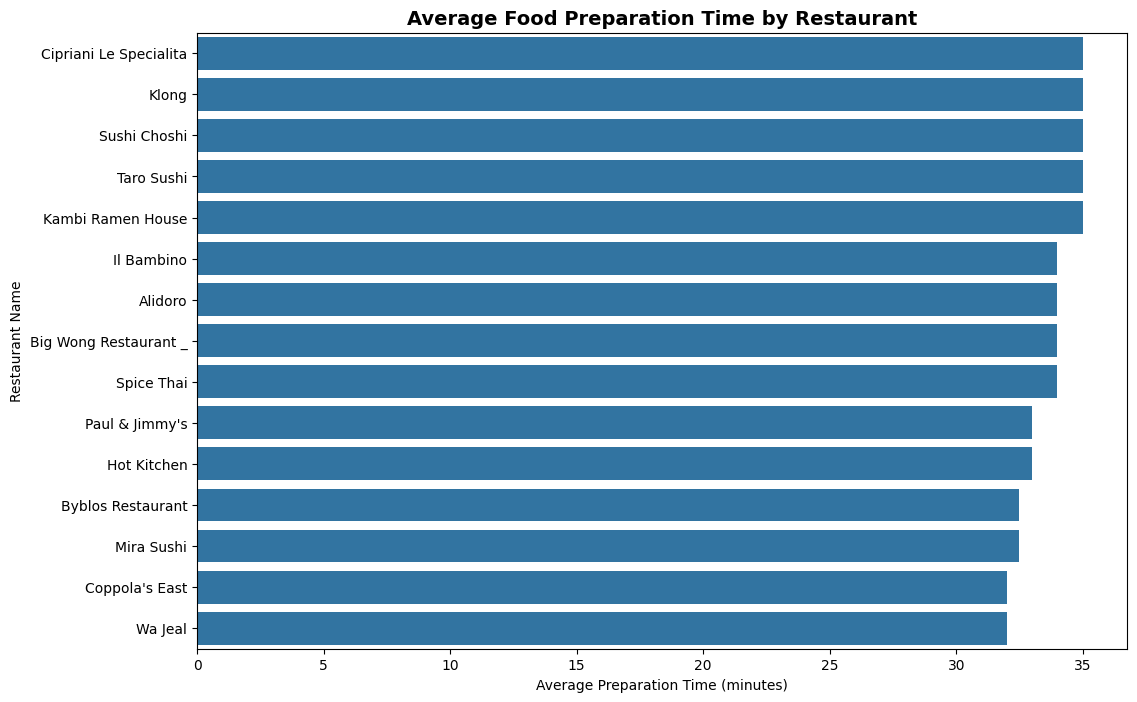

In [ ]:
# Calculate average preparation time per restaurant
avg_prep_time = df.groupby("restaurant_name")["food_preparation_time"].mean().reset_index()

# Sort descending by average preparation time
avg_prep_time = avg_prep_time.sort_values(by="food_preparation_time", ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(data=avg_prep_time.head(15),y="restaurant_name",x="food_preparation_time")# top 15 restaurants for clarity
plt.title("Average Food Preparation Time by Restaurant", fontsize=14, weight="bold")
plt.xlabel("Average Preparation Time (minutes)")
plt.ylabel("Restaurant Name")
plt.show()



* Preparation times differ moderately across restaurants.

### **Cuisine type vs Cost of the order**

In [ ]:
#Calculate average order cost by cuisine
avg_cost_by_cuisine = (df.groupby('cuisine_type')['cost_of_the_order'].mean().sort_values(ascending=False))

avg_cost_by_cuisine

,cost_of_the_order
cuisine_type,
French,19.794
Southern,19.301
Thai,19.208
Spanish,18.994
Middle Eastern,18.821
Mexican,16.933
Indian,16.920
Italian,16.419
American,16.320


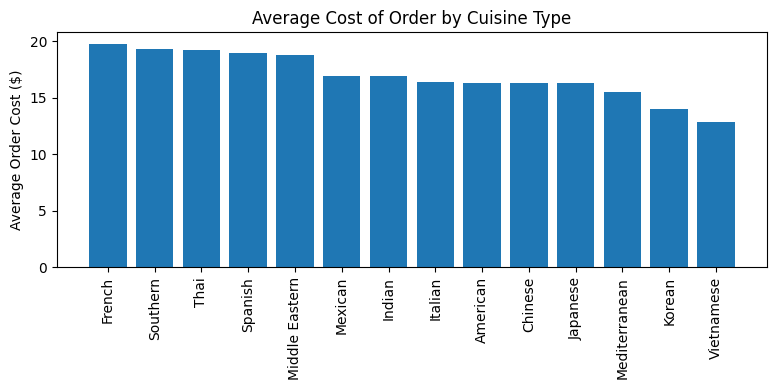

In [ ]:
plt.figure(figsize=(8,4))
plt.bar(avg_cost_by_cuisine.index, avg_cost_by_cuisine.values)
plt.xticks(rotation=90)
plt.ylabel("Average Order Cost ($)")
plt.title("Average Cost of Order by Cuisine Type")
plt.tight_layout()
plt.show()

* Higher average cost cuisines:
1.   French
2.   Southern
3.   Thai






### **Cusisine type vs Delivery time**

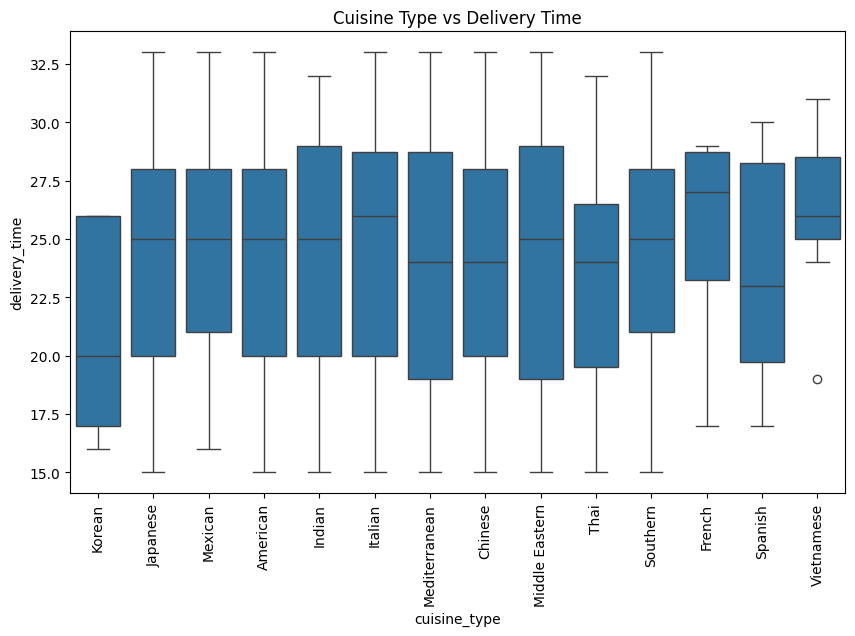

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="cuisine_type", y="delivery_time")
plt.xticks(rotation=90)
plt.title("Cuisine Type vs Delivery Time")
plt.show()


* Delivery times remain fairly consistent across different cuisine types, with only minor variations.

### **Cuisine Type vs Rating**

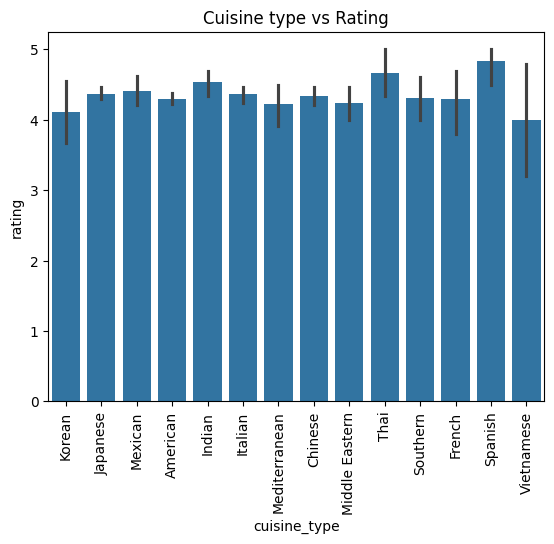

In [ ]:
sns.barplot(data=df, x='cuisine_type', y='rating')
plt.xticks(rotation=90)
plt.title("Cuisine type vs Rating")
plt.show()

* Customer ratings remain consistently high across all cuisine types, with only minor variations

### **Delivery Time vs Rating**

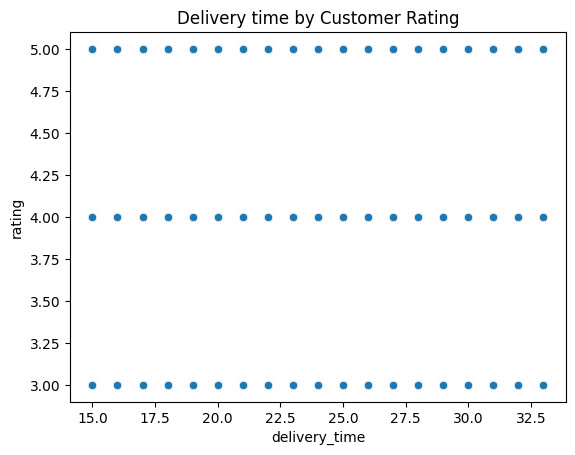

In [ ]:
sns.scatterplot(data=df, x='delivery_time', y='rating')
plt.title("Delivery time by Customer Rating")
plt.show()

* Customer ratings remain consistently high across different delivery times, with most ratings clustered between 3 and 5 regardless of whether delivery takes around 15 minutes or over 30 minutes. This indicates that delivery time alone does not strongly influence customer satisfaction

### **Rating vs Preparation Time**

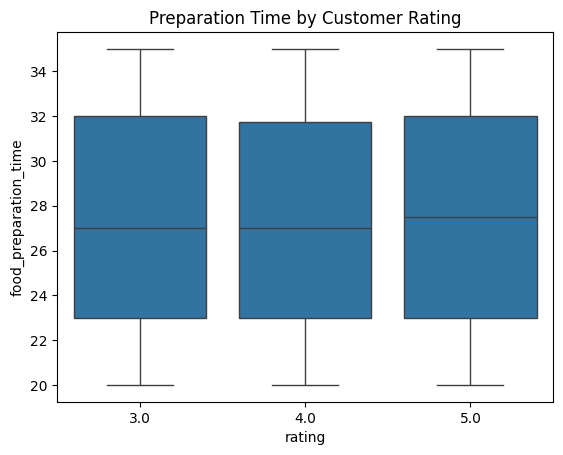

In [ ]:
sns.boxplot(data=df, x="rating", y="food_preparation_time")
plt.title("Preparation Time by Customer Rating")
plt.show()


* Customer ratings do not show a strong relationship with preparation time.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
# Write the code here
# remove 'Not given' ratings and convert to numeric
ratings_df = df[df['rating'] != 'Not given'].copy()
ratings_df['rating'] = ratings_df['rating'].astype(float)

restaurants_data = ratings_df.groupby('restaurant_name').agg(
    rating_count=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()

# Apply conditions
eligible_restaurants = restaurants_data[
    (restaurants_data['rating_count'] > 50) & (restaurants_data['avg_rating'] > 4)
]

eligible_restaurants

,restaurant_name,rating_count,avg_rating
20,Blue Ribbon Fried Chicken,64,4.328
21,Blue Ribbon Sushi,73,4.219
136,Shake Shack,133,4.278
153,The Meatball Shop,84,4.512


#### Observations:
* The restaurants fulfilling the criteria to get the promotional offer are
1.   Blue Ribbon Fried Chicken
2.   Blue Ribbon Sushi
3.   Shake Shack
4.   The Meatball Shop


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
# Write the code here
def calculate_revenue(cost):
  if(cost > 20):
    return cost * 0.25
  elif(cost > 5):
    return cost * 0.15
  else:
    return 0

df['company_revenue'] = df['cost_of_the_order'].apply(calculate_revenue)
total_revenue = round(df['company_revenue'].sum(), 2)
print("Net revenue generated by the company across all orders: $",total_revenue)

Net revenue generated by the company across all orders: $ 6166.3


#### Observations:
* Net revenue generated by the company across all orders: $ 6166.3


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
# Write the code here
# Total time = preparation + delivery
df['total_time_for_order'] = df['food_preparation_time']+df['delivery_time']

total_orders = df.shape[0]
orders_more_than_60min = df[df['total_time_for_order']>60].shape[0]

orders_more_than_60min_percentage = (orders_more_than_60min/total_orders)*100
print("Percentage of orders taking more than 60 minutes:", round(orders_more_than_60min_percentage, 2), "%")

Percentage of orders taking more than 60 minutes: 10.54 %


#### Observations:
* Percentage of orders taking more than 60 minutes: 10.54 %


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [ ]:
# Write the code here
#calculate the mean
mean_delivery_time = df.groupby('day_of_the_week')['delivery_time'].mean().reset_index()
mean_delivery_time



,day_of_the_week,delivery_time
0,Weekday,28.340
1,Weekend,22.470


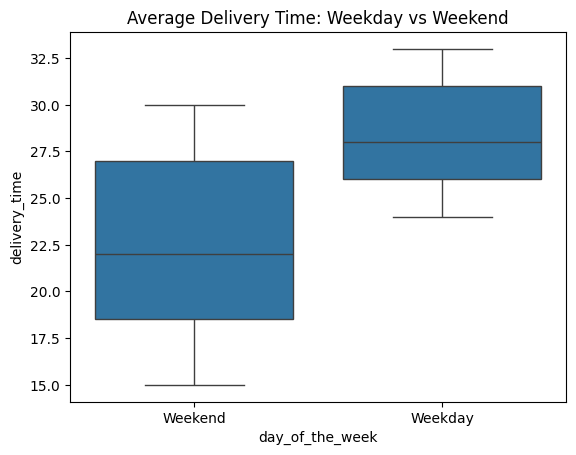

In [ ]:
#Visualize the mean delivery time during weekdays and weekends
sns.boxplot(data=df, x='day_of_the_week', y='delivery_time')
plt.title("Average Delivery Time: Weekday vs Weekend")
plt.show()

#### Observations:
* The mean delivery time is higher on weekdays (28.34 minutes) compared to weekends (22.47 minutes), indicating faster deliveries during weekends.


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### **Conclusions:**
**Operational Performance:**
* Delivery time remains relatively constant across different order cost levels and cuisine types, indicating stable operational efficiency across categories.

* However, delivery performance varies by day type. The mean delivery time is higher on weekdays (28.34 minutes) compared to weekends (22.47 minutes), suggesting that deliveries are faster and potentially better managed during weekends.

* Additionally, while average delivery times vary slightly across restaurants, most fall within a narrow range of approximately 23–26 minutes, reflecting overall consistency in service levels.

**Cost and Cusinine:**
* Order costs show similar distributions across weekdays and weekends, with slightly more high-value orders occurring during weekends.

* American and Japanese cuisines receives the highest number of orders on weekends, making it the most popular cuisine.

* Among cuisines, French, Southern, and Thai cuisines have the highest average order costs, indicating that these represent premium, higher-revenue categories.

**Customer Satisfaction:**
* Customer ratings remain consistently high across all cuisine types, with only minor variations.

* Ratings also remain stable across different delivery times, with most ratings clustered between 3 and 5 regardless of whether delivery takes around 15 minutes or over 30 minutes. This suggests that delivery time alone does not strongly influence customer satisfaction.

### Recommendations:

**1. Optimize Weekday Delivery Operations**

Since delivery times are higher on weekdays compared to weekends, FoodHub should focus on improving weekday logistics by:

* Increasing delivery partner availability during peak weekday hours

* Optimizing delivery routes using demand patterns

* Introducing weekday performance incentives for faster deliveries

**Expected impact:** Reduced delivery times, improved service consistency, and higher customer satisfaction.

**2.** **Leverage Premium Cuisines for Revenue Growth**

French, Southern, and Thai cuisines show higher average order costs and represent premium revenue opportunities.

FoodHub should:

* Feature these cuisines in promotional campaigns

* Offer premium meal bundles and upselling options

* Highlight top-performing restaurants within these cuisines

**Expected impact:** Higher average order value and increased commission revenue.

**3. Continue Promoting High-Demand Cuisines on Weekends**

American and Japanese cuisines receive the highest order volumes during weekends.

FoodHub should:

* Run weekend-specific promotions and combo offers

* Ensure sufficient delivery resources for peak weekend demand

* Partner with popular restaurants for exclusive deals

**Expected impact:** Sustained high order volume and improved customer retention.

**4. Enhance Customer Feedback Collection**

Given consistently high satisfaction but many unrated orders:

* Introduce post-delivery rating reminders

* Offer small incentives for providing feedback

* Simplify the rating process within the app

**Expected impact:** Better quality data and early identification of service issues.

* FoodHub should improve weekday delivery efficiency, capitalize on premium high-value cuisines for revenue growth, continue supporting high-demand cuisines during peak periods, standardize restaurant performance, and strengthen customer feedback mechanisms to further enhance customer experience and profitability.